In [1]:
import pandas as pd
import glob
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Verify that the source files are structured identically
files = glob.glob("bquxjob_*.csv")
headers = [pd.read_csv(f, nrows=0).columns.tolist() for f in files]
all_same = all(h == headers[0] for h in headers)

all_same

True

In [3]:
# Read the source files and merge them into a single DataFrame
df_list = [pd.read_csv(f) for f in files]
df_merged = pd.concat(df_list, ignore_index=True)

df_merged.shape

(162965, 82)

In [4]:
# Sort the data by category, UPC, and week_ending
df_merged = df_merged.sort_values(["category", "upc", "week_ending"])
df_merged.head()

,category,niagara_personal_chars,niagara_personal_chars_alias,l1,l2,markets,generic_tag,retailers_name_tag,retailers_div_req,item,...,Holiday_Eastern_Easter,Holiday_Memorial_Day,Holiday_Veterans_Day,Holiday_Valentine_s_Day_n_Washington_s_Birthday,Holiday_New_Year_s_Day,Holiday_Labor_Day,Holiday_Eastern_Easter_n_Western_Easter,Holiday_Christmas_Day,Holiday_Columbus_Day,Holiday_clubbed
11954,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
14756,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
17554,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
84314,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False
87119,HEALTH/NUTRITION SHAKES,PC_Health Nutrition Shakes,PC_Protein Shakes,Census Divisions,xAOC,Pacific Division xAOC,Census Divisions,Census Divisions_xAOC,NaN,SLMF MSCL SPRT DRNG WGHT LS VRY VNL SHK CRTN 4...,...,False,False,False,False,False,False,False,False,False,False


In [5]:
# Store the unique category values in a list
categories = df_merged["category"].unique().tolist()
categories

['HEALTH/NUTRITION SHAKES',
 'MEAL REPLACEMENT SHAKES',
 'PERFORMANCE NUTRITION SHAKES',
 'SPORT DRINKS',
 'VALUE ADD WATER',
 'WATER',
 nan]

In [6]:
# Select a Category to focus on and filter df_merged
ACTIVE_CATEGORY = categories[5]
ACTIVE_CATEGORY

'WATER'

In [7]:
# Filter df_merged for the selected category and store it in a separate data frame
df_active = df_merged[df_merged["category"] == ACTIVE_CATEGORY].copy()
df_active.shape

(41983, 82)

In [8]:
# Define a price promotion flag
df_active["price_promo"] = (
    df_active["price_decr_only_prc_acv"] > 0
)

In [9]:
# Define how many other SKUs in the category have a price promotion
df_active["competitor_promo_count"] = (
    df_active.groupby("week_ending")["price_promo"]
             .transform("sum")
    - df_active["price_promo"].astype(int)
)

In [10]:
### Exploratory Data Analysis

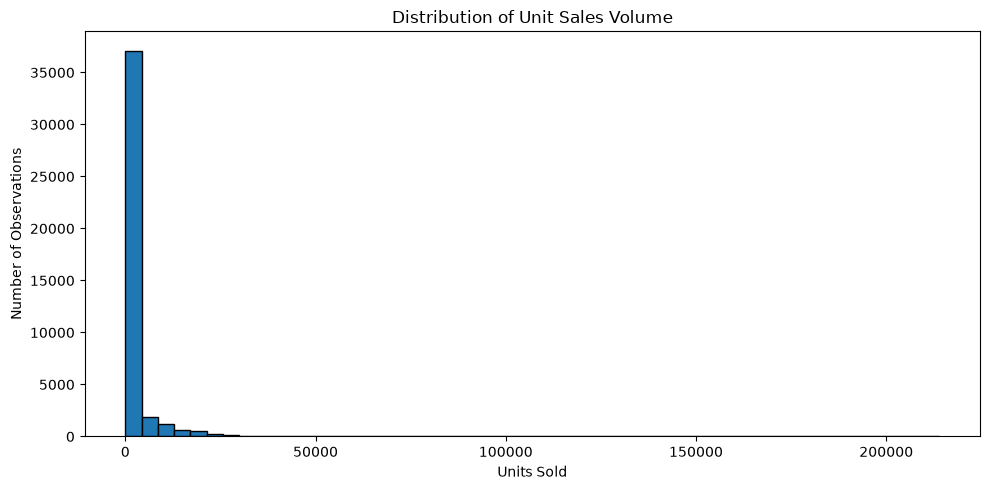

In [11]:
## Examine the distribution of units i.e response variable
plt.figure(figsize=(10, 5))

plt.hist(df_active["units"], bins=50, edgecolor="black")

plt.title("Distribution of Unit Sales Volume")
plt.xlabel("Units Sold")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

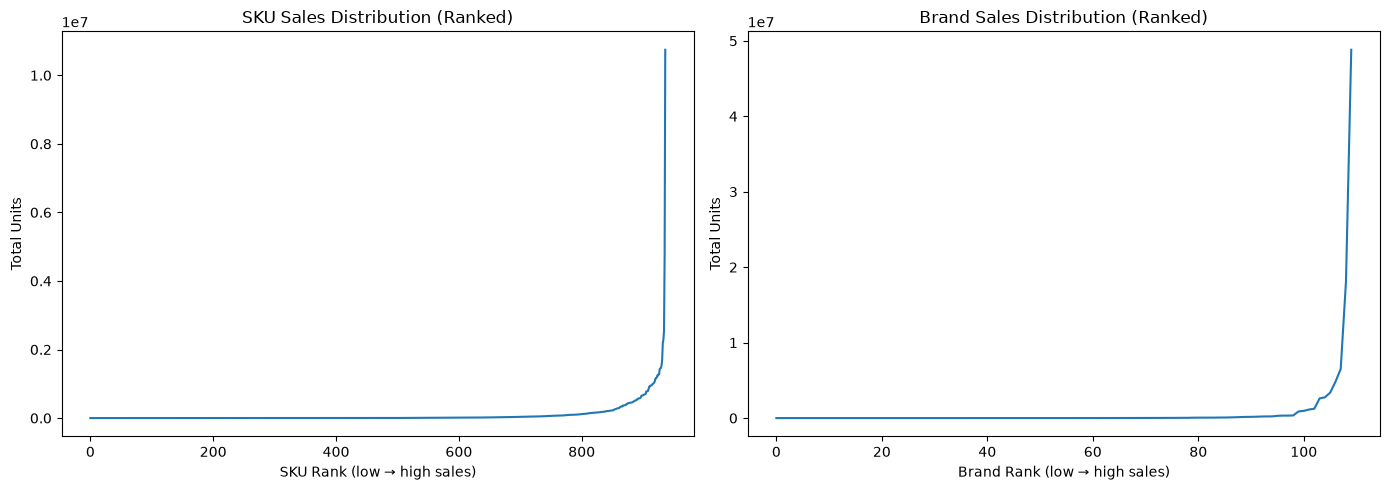

In [12]:
## Examine the distribution of SKU and brand performance in terms of total units sold

sku_units = df_active.groupby("upc")["units"].sum().sort_values()
brand_units = df_active.groupby("brand")["units"].sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# SKU sales distribution
axes[0].plot(sku_units.values)
axes[0].set_title("SKU Sales Distribution (Ranked)")
axes[0].set_xlabel("SKU Rank (low → high sales)")
axes[0].set_ylabel("Total Units")

# Brand sales distribution
axes[1].plot(brand_units.values)
axes[1].set_title("Brand Sales Distribution (Ranked)")
axes[1].set_xlabel("Brand Rank (low → high sales)")
axes[1].set_ylabel("Total Units")

plt.tight_layout()
plt.show()

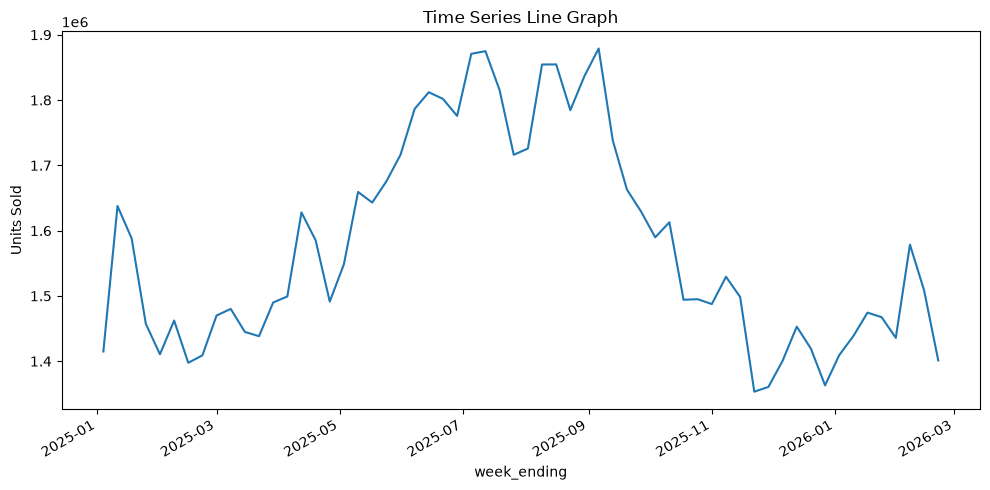

In [13]:
## Plot time-series data between week_ending and units
df_active["week_ending"] = pd.to_datetime(df_active["week_ending"])

weekly_units = df_active.groupby("week_ending")["units"].sum()

plt.figure(figsize=(10,5))
plt.plot(weekly_units.index, weekly_units.values)

plt.title("Time Series Line Graph")
plt.xlabel("week_ending")
plt.ylabel("Units Sold")

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

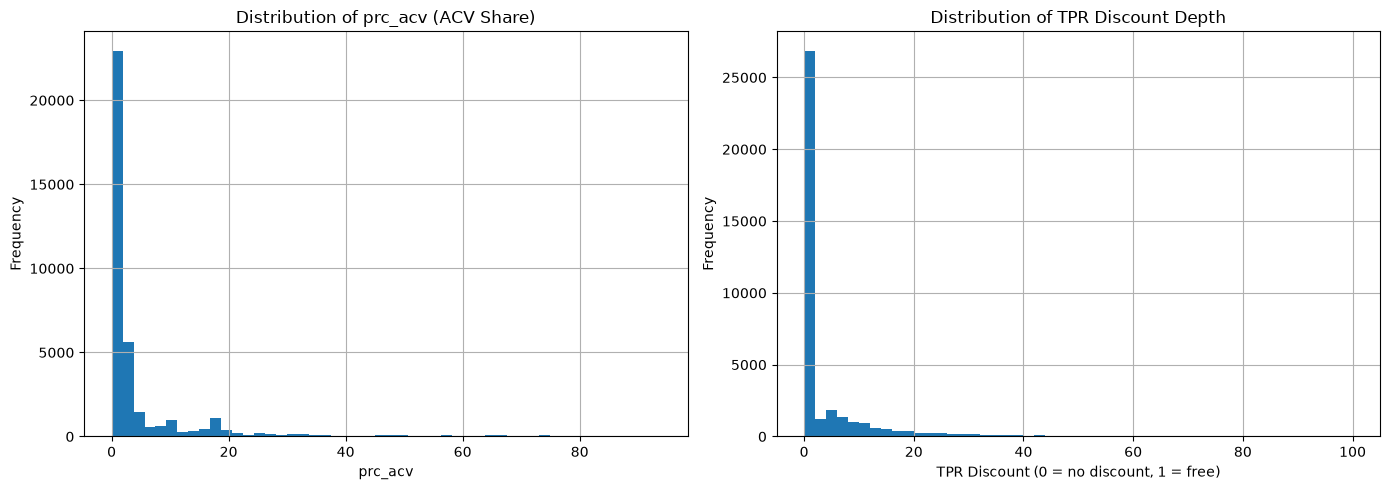

In [14]:
# Examine the frequency distributions of prc_acv and tpr_discount

fig, axes = plt.subplots(1, 2, figsize=(14,5))

df_active["prc_acv"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution of prc_acv (ACV Share)")
axes[0].set_xlabel("prc_acv")
axes[0].set_ylabel("Frequency")

df_active["tpr_discount"].hist(bins=50, ax=axes[1])
axes[1].set_title("Distribution of TPR Discount Depth")
axes[1].set_xlabel("TPR Discount (0 = no discount, 1 = free)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

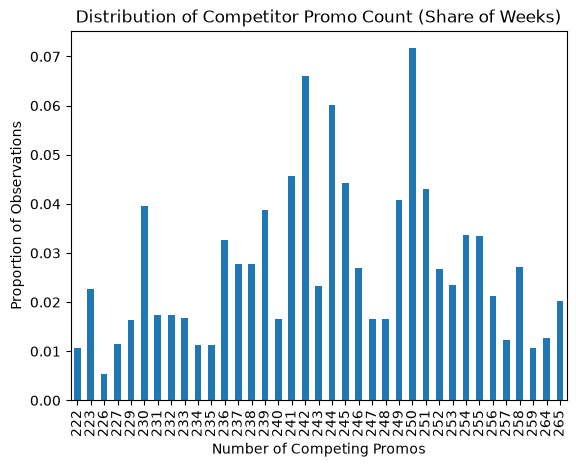

In [15]:
# Examine the competitive nature of price promotions within the category
(df_active["competitor_promo_count"]
 .value_counts(normalize=True)
 .sort_index()
 .plot(kind="bar"))

plt.title("Distribution of Competitor Promo Count (Share of Weeks)")
plt.xlabel("Number of Competing Promos")
plt.ylabel("Proportion of Observations")
plt.show()

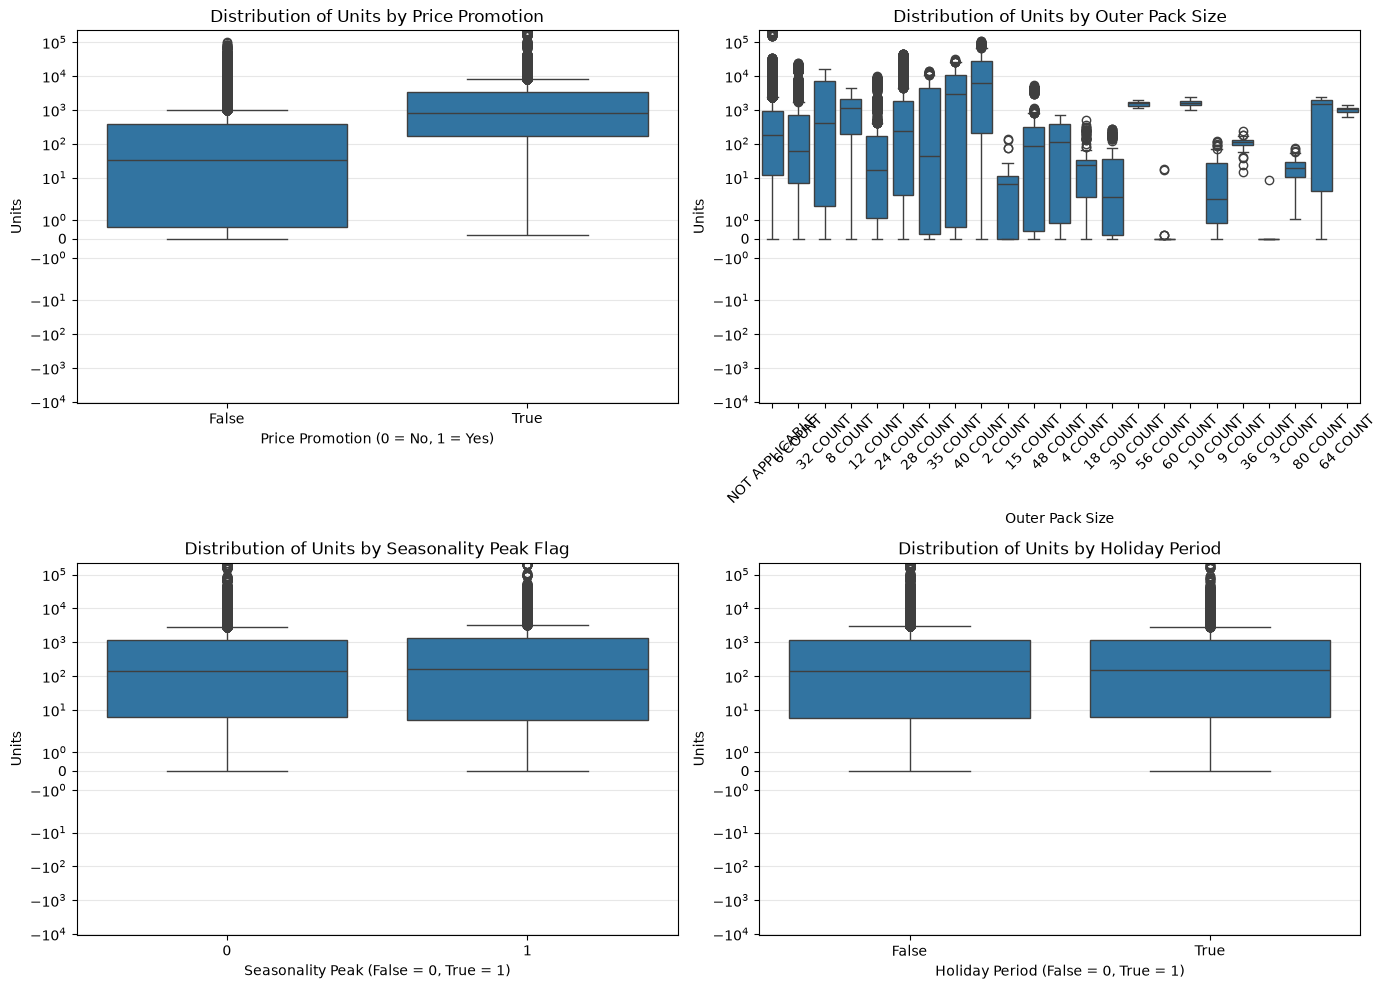

In [16]:
## Create boxplots for relevant categorical or binary predictors

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# price_promo
sns.boxplot(
    x="price_promo",
    y="units",
    data=df_active,
    showfliers=True,
    ax=axes[0,0]
)

axes[0,0].set_title("Distribution of Units by Price Promotion")
axes[0,0].set_xlabel("Price Promotion (0 = No, 1 = Yes)")
axes[0,0].set_ylabel("Units")
axes[0,0].set_yscale("symlog")
axes[0,0].grid(axis="y", alpha=0.3)


# outer_pack_size
sns.boxplot(
    x="outer_pack_size",
    y="units",
    data=df_active,
    showfliers=True,
    ax=axes[0,1]
)

axes[0,1].set_title("Distribution of Units by Outer Pack Size")
axes[0,1].set_xlabel("Outer Pack Size")
axes[0,1].set_ylabel("Units")
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].set_yscale("symlog")
axes[0,1].grid(axis="y", alpha=0.3)


# seasonality_peak_flag
sns.boxplot(
    x="seasonality_peak_flag",
    y="units",
    data=df_active,
    showfliers=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Distribution of Units by Seasonality Peak Flag")
axes[1,0].set_xlabel("Seasonality Peak (False = 0, True = 1)")
axes[1,0].set_ylabel("Units")
axes[1,0].set_yscale("symlog")
axes[1,0].grid(axis="y", alpha=0.3)


# Holiday_clubbed
sns.boxplot(
    x="Holiday_clubbed",
    y="units",
    data=df_active,
    showfliers=True,
    ax=axes[1,1]
)

axes[1,1].set_title("Distribution of Units by Holiday Period")
axes[1,1].set_xlabel("Holiday Period (False = 0, True = 1)")
axes[1,1].set_ylabel("Units")
axes[1,1].set_yscale("symlog")
axes[1,1].grid(axis="y", alpha=0.3)


plt.tight_layout()
plt.show()